<a href="https://colab.research.google.com/github/NadavLib/ML/blob/main/ML_Project_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading the Data Set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



url = "https://raw.githubusercontent.com/NadavLib/ML/main/sentiment.csv"
df = pd.read_csv(url)
df.head()








,id,text,sentiment,type,post_datetime,timezone,post_likes,posts_retweets,embedded_content_url,username,checkmark,account_creation_date,email,birthday,followers,profile_picture,previous_posts_count
0,2f2c6353-32b9-4432-b285-39ac9102bb03,i feel selfish when i send a chapter because i...,negative,post,21/08/2025 20:35,AEST,63,31,https://assets.storage.net/1dacdb5c-dbae-4982-...,@user6423,none,27/06/2016,david.green4296@yahoo.it,13/01/2006,365,https://placekitten.com/768/456,144
1,d61d3af4-e568-4a9d-8f16-b6ce98da2b60,i couldnt help feeling like this scene was goi...,positive,retweet,13/10/2021 10:04,EET,53,2,NaN,@brian_han,none,12/10/2021,brianhansen5416@yahoo.com.br,07/08/1993,32,NaN,0
2,08661df4-3ff2-4092-8c72-98734c7a7aea,i liked it for its free feeling and i really l...,positive,reply,08/03/2022 09:21,GMT,51,4,NaN,@thomasz5t,none,07/04/2018,thomas_williams4935@live.nl,26/12/1980,47,https://placekitten.com/0/865,90
3,538a4160-18f0-4344-a0d0-a421224ace84,i retreat ended i woke up feeling extremely ag...,negative,post,04/02/2023 20:32,MSK,28,4,https://assets.storage.net/9d0a975e-8f6b-49a3-...,@door2739,blue,03/02/2023,michaelmiller1564@yahoo.com,26/10/1985,13,https://placekitten.com/104/26,0
4,66ce15b4-5070-4430-8c08-4bead309acb2,i have been thinking hard about all that feeli...,negative,post,13/11/2025 15:30,PST,51,14,https://assets.storage.net/a218a3d0-b0e9-4819-...,@56emrl3f,none,26/04/2019,robertfox3470@bellsouth.net,19/04/1987,118,https://placekitten.com/882/971,49


#Exploratory Data Analysis

In [2]:
numericcols = ['post_likes','posts_retweets','account_creation_date','birthday','followers','previous_posts_count']
catcol=['timezone','sentiment','type','checkmark']

#

for col in numericcols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].info()
    print(df[col].describe())
    print("\ndtype:")
    print(df[col].dtype)
    print("\nvalue counts:")
    print(df[col].value_counts())
    print("\nmissing values:")
    print(df[col].isnull().sum())



#df['post_datetime'] = pd.to_datetime(df['post_datetime'])

<class 'pandas.core.series.Series'>
RangeIndex: 40000 entries, 0 to 39999
Series name: post_likes
Non-Null Count  Dtype  
--------------  -----  
39514 non-null  float64
dtypes: float64(1)
memory usage: 312.6 KB
count    39514.000000
mean       349.910310
std       1304.628857
min         20.000000
25%         57.000000
50%         85.000000
75%        183.000000
max      29508.000000
Name: post_likes, dtype: float64

dtype:
float64

value counts:
post_likes
51.0       772
50.0       764
52.0       688
53.0       674
45.0       652
          ... 
1471.0       1
6907.0       1
2530.0       1
8781.0       1
15341.0      1
Name: count, Length: 2686, dtype: int64

missing values:
486
<class 'pandas.core.series.Series'>
RangeIndex: 40000 entries, 0 to 39999
Series name: posts_retweets
Non-Null Count  Dtype  
--------------  -----  
39514 non-null  float64
dtypes: float64(1)
memory usage: 312.6 KB
count    39514.000000
mean        48.690768
std        276.914008
min          0.000000
25%    

**Sentimet Distribution**

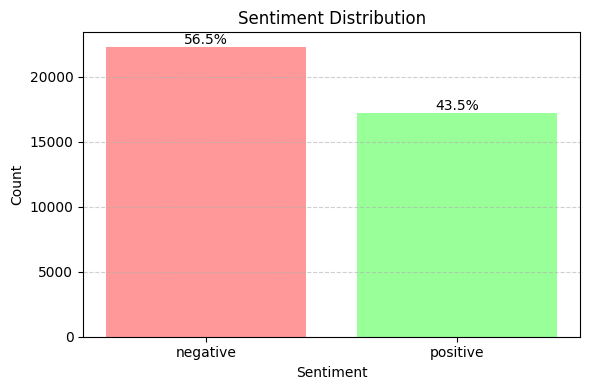

In [ ]:
# Filter out rows where sentiment is missing ('?')
sentiment_counts = df[df['sentiment'] != '?']['sentiment'].value_counts()
total = sentiment_counts.sum()

# Define light colors for each sentiment
colors = {
    'positive': '#99FF99',  # Light green
    'negative': '#FF9999'   # Light red
}

# Create the bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(sentiment_counts.index,
               sentiment_counts.values,
               color=[colors.get(s, 'gray') for s in sentiment_counts.index])

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + 5,
             f'{percent:.1f}%',
             ha='center',
             va='bottom',
             fontsize=10)

# Customize chart
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Distribution of Post Types by Sentiment**

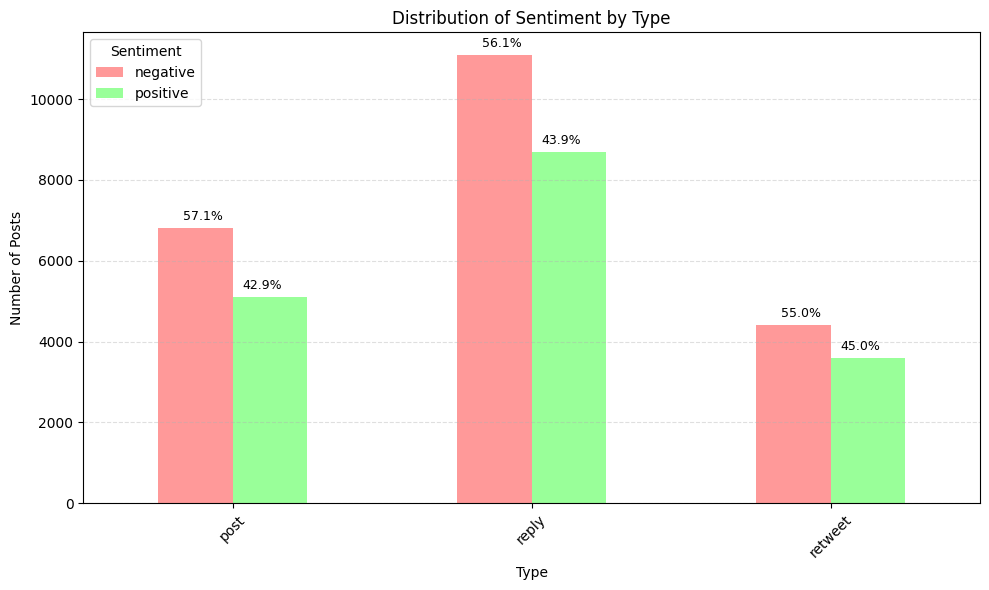

In [ ]:
# Sample cross-tabulated data (replace with your real df if needed)
data = {
    'negative': [6800, 11100, 4400],
    'positive': [5100, 8700, 3600]
}
index = ['post', 'reply', 'retweet']
cross_tab = pd.DataFrame(data, index=index)

# Calculate total and percent per row
totals = cross_tab.sum(axis=1)
percentages = cross_tab.divide(totals, axis=0) * 100

# Plot
ax = cross_tab.plot(kind='bar', figsize=(10, 6), color=['#FF9999', '#99FF99'])

# Add percentage labels
for i, type_ in enumerate(cross_tab.index):
    for j, sentiment in enumerate(cross_tab.columns):
        count = cross_tab.loc[type_, sentiment]
        pct = percentages.loc[type_, sentiment]
        ax.text(i + j * 0.2 - 0.1, count + 200, f'{pct:.1f}%', ha='center', fontsize=9)

# Customize plot
plt.title('Distribution of Sentiment by Type')
plt.xlabel('Type')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**Sentiment distribution by hour**

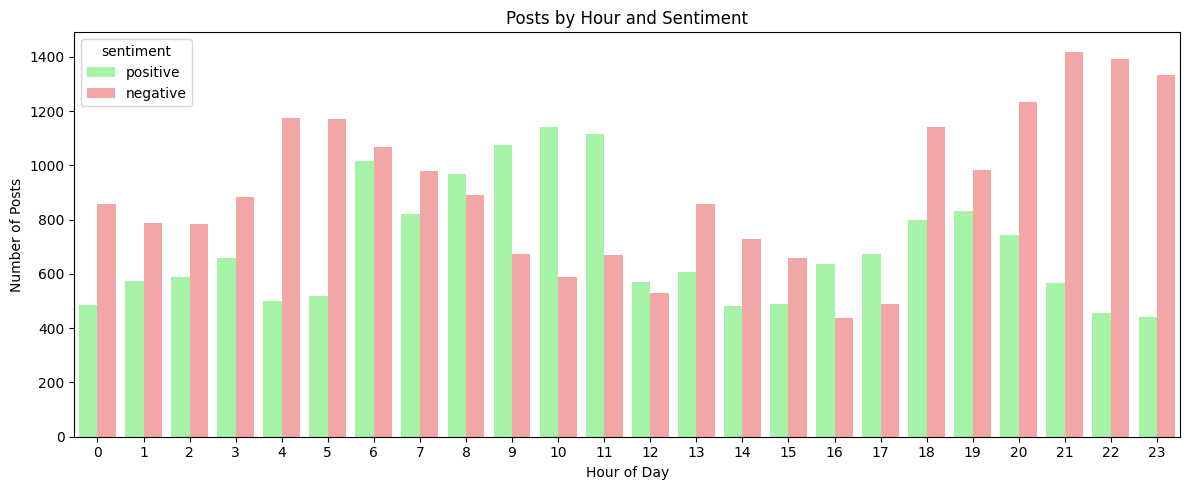

In [ ]:
# Clean dataframe: only rows without '?'
clean_df = df[~df.apply(lambda row: row.astype(str).str.contains('\?')).any(axis=1)].copy()

# Convert post_datetime to datetime
clean_df['post_datetime'] = pd.to_datetime(clean_df['post_datetime'], errors='coerce')

# Extract date and hour
clean_df['post_date'] = clean_df['post_datetime'].dt.date
clean_df['post_hour'] = clean_df['post_datetime'].dt.hour

# Set color palette (light red for negative, light green for positive)
palette = {'negative': '#FF9999', 'positive': '#99FF99'}


#Plot by hour
plt.figure(figsize=(12, 5))
sns.countplot(data=clean_df, x='post_hour', hue='sentiment', palette=palette)
plt.title('Posts by Hour and Sentiment')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

**Sentiment distribution by Year**

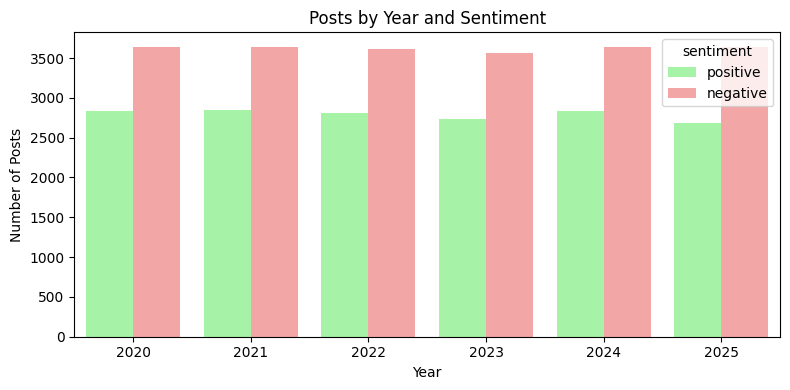

In [ ]:
# Clean dataframe: only rows without '?'
clean_df = df[~df.apply(lambda row: row.astype(str).str.contains('\?')).any(axis=1)].copy()

# Convert post_datetime to datetime
clean_df['post_datetime'] = pd.to_datetime(clean_df['post_datetime'], errors='coerce')

# Extract year and month
clean_df['post_year'] = clean_df['post_datetime'].dt.year
clean_df['post_month'] = clean_df['post_datetime'].dt.month

# Custom colors for sentiment
palette = {'negative': '#FF9999', 'positive': '#99FF99'}

# Plot: Posts by Year
plt.figure(figsize=(8, 4))
sns.countplot(data=clean_df, x='post_year', hue='sentiment', palette=palette)
plt.title('Posts by Year and Sentiment')
plt.xlabel('Year')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()


**Sentiment distribution by Month**

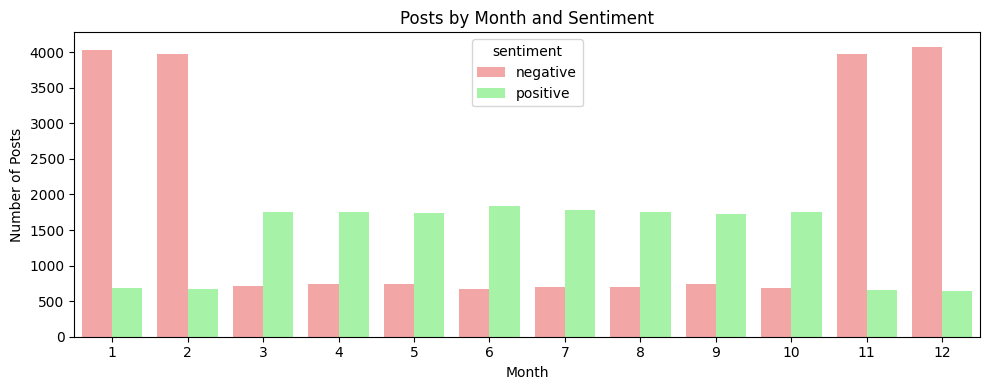

In [ ]:
# Plot: Posts by Month
plt.figure(figsize=(10, 4))
sns.countplot(data=clean_df, x='post_month', hue='sentiment', palette=palette)
plt.title('Posts by Month and Sentiment')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

**Sentiment Distribution by Timezone**

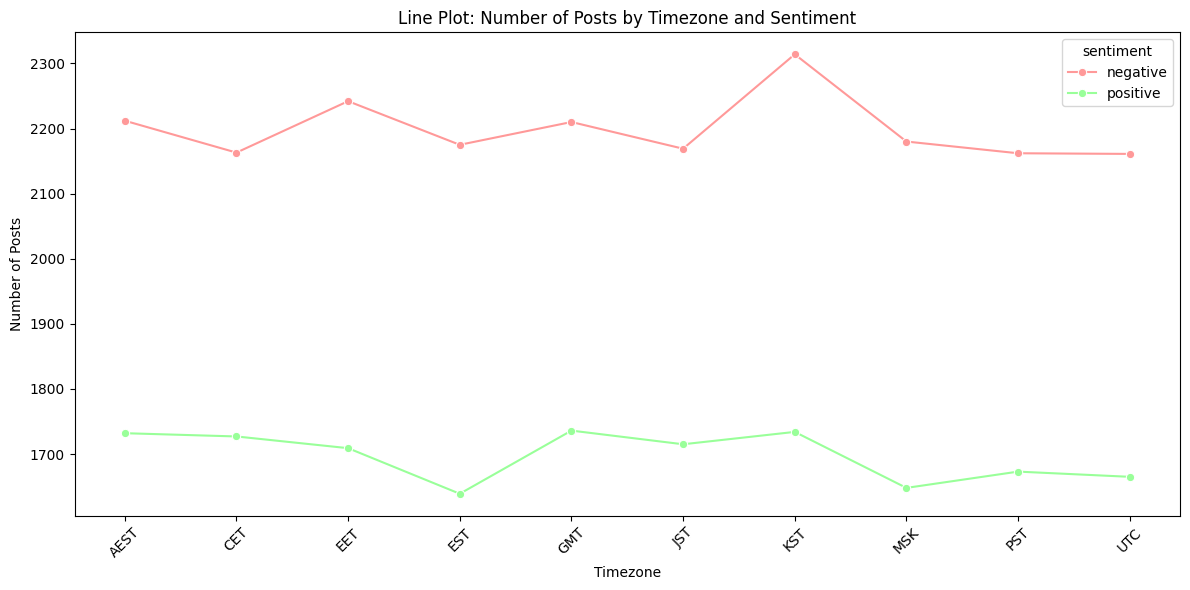

In [ ]:

# Clean the data – remove rows with '?' in timezone or sentiment
line_df = df[~df[['timezone', 'sentiment']].apply(lambda col: col.astype(str).str.contains('\?')).any(axis=1)].copy()

# Group by timezone and sentiment
line_counts = line_df.groupby(['timezone', 'sentiment']).size().reset_index(name='count')

# Sort timezones alphabetically (or you can define custom order if needed)
line_counts = line_counts.sort_values('timezone')

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=line_counts, x='timezone', y='count', hue='sentiment',
             palette={'negative': '#FF9999', 'positive': '#99FF99'},
             marker='o')

plt.title('Line Plot: Number of Posts by Timezone and Sentiment')
plt.xlabel('Timezone')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Distribution of Post Likes by Sentiment**

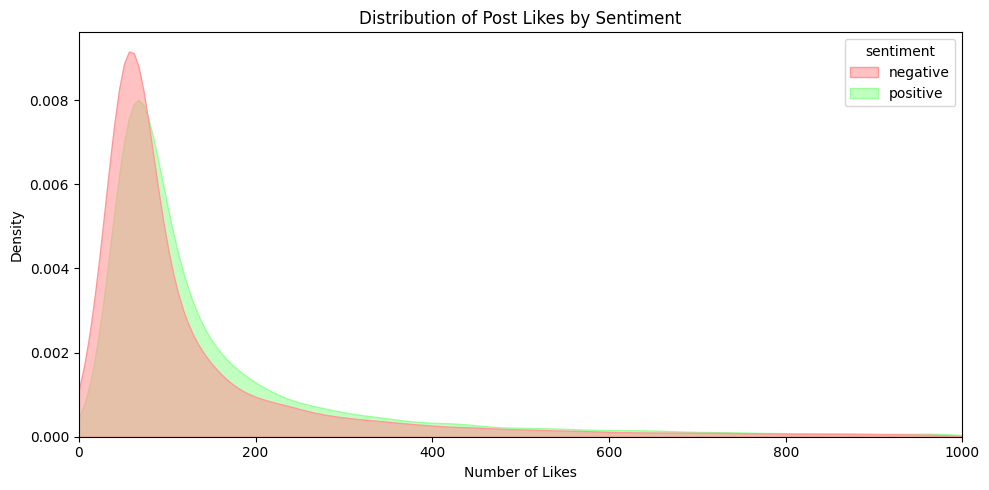

In [ ]:

# Clean data: remove rows with '?' in relevant columns
ridge_df = df[~df[['post_likes', 'sentiment']].apply(lambda col: col.astype(str).str.contains('\?')).any(axis=1)].copy()

# Convert post_likes to numeric
ridge_df['post_likes'] = pd.to_numeric(ridge_df['post_likes'], errors='coerce')

# Drop NaNs and limit outliers
ridge_df = ridge_df.dropna(subset=['post_likes'])
ridge_df = ridge_df[ridge_df['post_likes'] <= 1000]

# Plot: KDE with fill by sentiment
plt.figure(figsize=(10, 5))
sns.kdeplot(data=ridge_df, x='post_likes', hue='sentiment',
            fill=True, common_norm=False, alpha=0.6,
            palette={'negative': '#FF9999', 'positive': '#99FF99'})

plt.title('Distribution of Post Likes by Sentiment')
plt.xlabel('Number of Likes')
plt.ylabel('Density')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

**Distribution of Post Retweets by Sentiment**

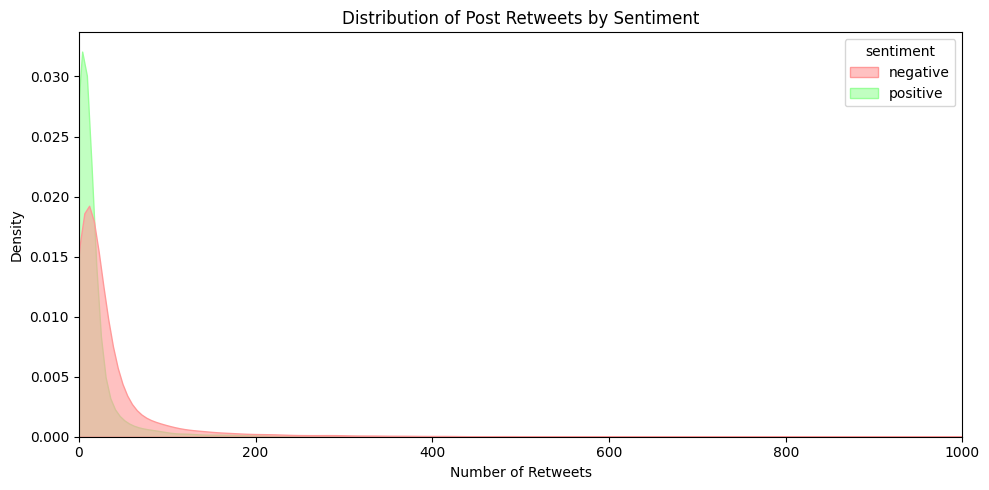

In [ ]:
# Clean data: remove rows with '?' in relevant columns
retweet_df = df[~df[['posts_retweets', 'sentiment']].apply(lambda col: col.astype(str).str.contains('\?')).any(axis=1)].copy()

# Convert posts_retweets to numeric
retweet_df['posts_retweets'] = pd.to_numeric(retweet_df['posts_retweets'], errors='coerce')

# Drop NaNs and limit outliers
retweet_df = retweet_df.dropna(subset=['posts_retweets'])
retweet_df = retweet_df[retweet_df['posts_retweets'] <= 1000]

# Plot: KDE with fill by sentiment
plt.figure(figsize=(10, 5))
sns.kdeplot(data=retweet_df, x='posts_retweets', hue='sentiment',
            fill=True, common_norm=False, alpha=0.6,
            palette={'negative': '#FF9999', 'positive': '#99FF99'})

plt.title('Distribution of Post Retweets by Sentiment')
plt.xlabel('Number of Retweets')
plt.ylabel('Density')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()


**Sentiment Distribution by Presence of Embedded Link**

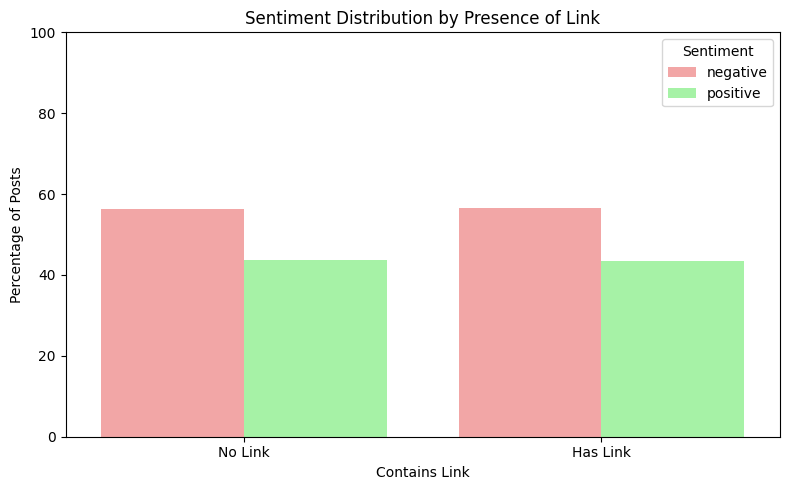

In [ ]:
# Step 1: Remove rows with '?' in sentiment or embedded_content_url
link_df = df[~df[['sentiment', 'embedded_content_url']].apply(lambda col: col.astype(str).str.contains('\?')).any(axis=1)].copy()

# Step 2: Create 'has_link' column: True if link contains 'http' or 'www'
link_df['has_link'] = link_df['embedded_content_url'].astype(str).str.contains('http|www', case=False, na=False)

# Step 3: Count sentiment per 'has_link' group
sentiment_counts = link_df.groupby(['has_link', 'sentiment']).size().reset_index(name='count')

# Step 4: Normalize counts to percentages within each group
total_counts = sentiment_counts.groupby('has_link')['count'].transform('sum')
sentiment_counts['percent'] = sentiment_counts['count'] / total_counts * 100

# Step 5: Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=sentiment_counts, x='has_link', y='percent', hue='sentiment',
            palette={'negative': '#FF9999', 'positive': '#99FF99'})

plt.title('Sentiment Distribution by Presence of Link')
plt.xlabel('Contains Link')
plt.ylabel('Percentage of Posts')
plt.xticks([0, 1], ['No Link', 'Has Link'])  # Customize x-axis labels
plt.ylim(0, 100)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


**Sentiment Distribution by Link Category**

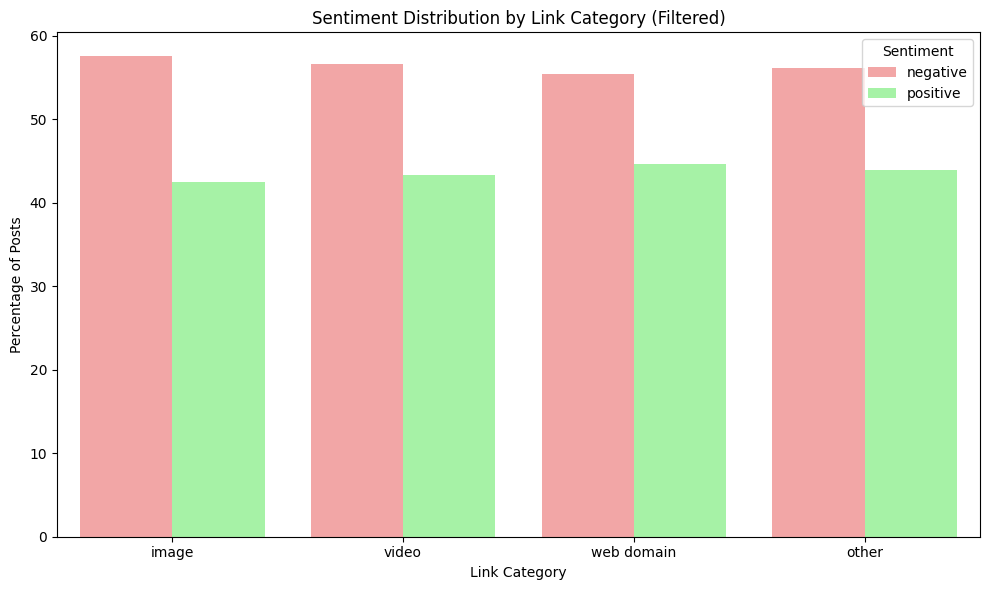

In [ ]:
# Step 1: Filter links with real embedded content
link_types_df = df[~df['embedded_content_url'].astype(str).str.contains('\?|nan', case=False, na=False)].copy()
link_types_df = link_types_df[link_types_df['embedded_content_url'].astype(str).str.contains('http|www', case=False)]

# Step 2: Extract file extensions and domain endings
link_types_df['link_type'] = link_types_df['embedded_content_url'].str.extract(r'\.([a-zA-Z0-9]+)$')[0].str.lower()
link_types_df['domain'] = link_types_df['embedded_content_url'].str.extract(r'\.([a-zA-Z0-9]+)[\/]?$')[0].str.lower()
link_types_df['link_type_combined'] = link_types_df['link_type'].fillna(link_types_df['domain'])

# Step 3: Categorize link types
def improved_categorize_link(ext):
    if ext in ['jpg', 'jpeg', 'png', 'gif', 'webp']:
        return 'image'
    elif ext in ['mp4', 'mov', 'avi', 'webm']:
        return 'video'
    elif ext in ['com', 'biz', 'info', 'net', 'org']:
        return 'web domain'
    else:
        return 'other'

link_types_df['link_category'] = link_types_df['link_type_combined'].apply(improved_categorize_link)

# Step 4: Filter out rows with '?' in sentiment
link_sentiment_df = link_types_df[~link_types_df['sentiment'].astype(str).str.contains('\?')].copy()

# Step 5: Count and normalize
link_sentiment_counts = link_sentiment_df.groupby(['link_category', 'sentiment']).size().reset_index(name='count')
total_per_category = link_sentiment_counts.groupby('link_category')['count'].transform('sum')
link_sentiment_counts['percent'] = link_sentiment_counts['count'] / total_per_category * 100

# Step 6: Remove 'document' and 'unknown' categories
filtered_counts = link_sentiment_counts[~link_sentiment_counts['link_category'].isin(['document', 'unknown'])].copy()

# Step 7: Define order for the remaining categories
filtered_category_order = ['image', 'video', 'web domain', 'other']
filtered_counts['link_category'] = pd.Categorical(filtered_counts['link_category'],
                                                  categories=filtered_category_order,
                                                  ordered=True)
filtered_counts = filtered_counts.sort_values('link_category')

# Step 8: Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=filtered_counts, x='link_category', y='percent', hue='sentiment',
            palette={'negative': '#FF9999', 'positive': '#99FF99'})

plt.title('Sentiment Distribution by Link Category (Filtered)')
plt.xlabel('Link Category')
plt.ylabel('Percentage of Posts')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


**Checkmark Distribution by Sentiment**

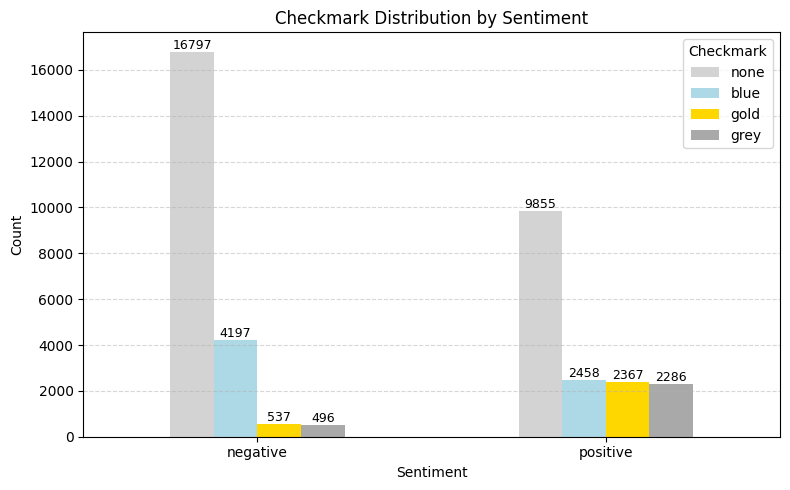

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter rows where 'sentiment' and 'checkmark' are valid (not '?')
df_filtered = df[(df['sentiment'] != '?') & (df['checkmark'] != '?')]

# Create cross-tab of sentiment vs checkmark
cross_tab = pd.crosstab(df_filtered['sentiment'], df_filtered['checkmark'])

# Define lighter colors for each checkmark category
checkmark_colors_light = {
    'none': '#D3D3D3',   # light gray
    'blue': '#ADD8E6',   # light blue
    'gold': '#FFD700',   # gold
    'grey': '#A9A9A9'    # soft dark gray
}

# Keep columns in specific order if they exist
columns_in_order = [col for col in ['none', 'blue', 'gold', 'grey'] if col in cross_tab.columns]

# Plot
ax = cross_tab[columns_in_order].plot(
    kind='bar',
    figsize=(8, 5),
    color=[checkmark_colors_light[col] for col in columns_in_order]
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=9)

# Customize the plot
plt.title('Checkmark Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Checkmark')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show plot
plt.show()


**Number of Posts by Account Creation Year and Sentiment**

<ipython-input-14-2c4f4661621f>:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Sentiment', loc='upper left')


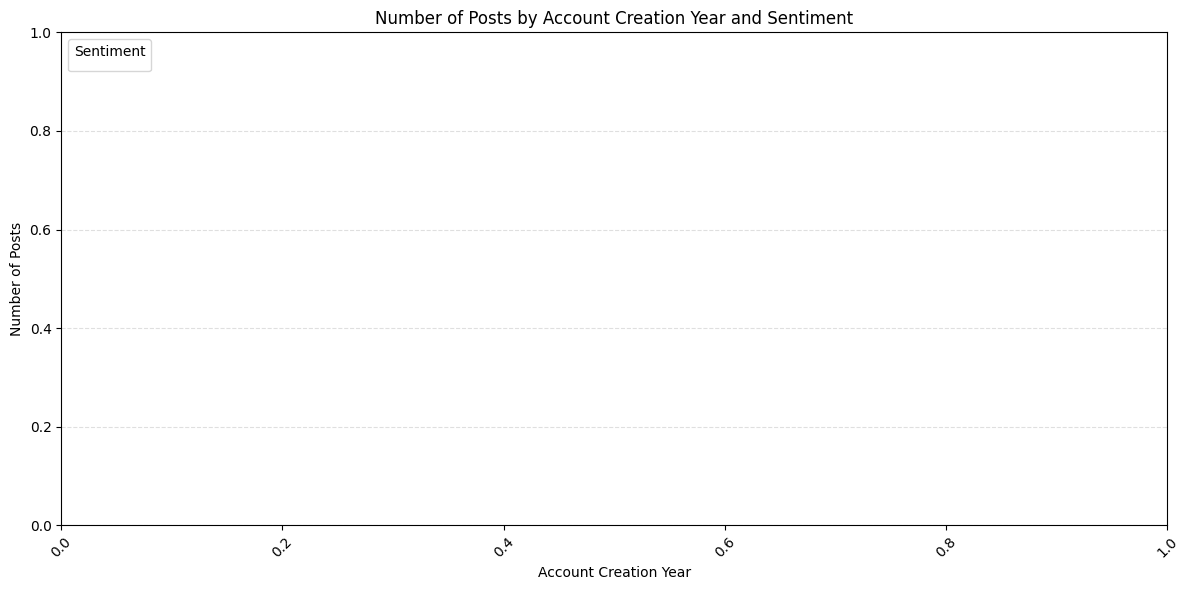

In [ ]:
#Filter out rows with invalid or missing 'account_creation_date' or 'sentiment'
account_df = df[~df[['account_creation_date', 'sentiment']].apply(lambda col: col.astype(str).str.contains('\?')).any(axis=1)].copy()

#Convert account_creation_date to datetime
account_df['account_creation_date'] = pd.to_datetime(account_df['account_creation_date'], errors='coerce')

#Extract year from account_creation_date
account_df['account_year'] = account_df['account_creation_date'].dt.year

#Group by year and sentiment
year_sentiment_counts = account_df.groupby(['account_year', 'sentiment']).size().reset_index(name='count')

#Plot counts
plt.figure(figsize=(12, 6))
sns.barplot(data=year_sentiment_counts, x='account_year', y='count', hue='sentiment',
            palette={'negative': '#FF9999', 'positive': '#99FF99'})

plt.title('Number of Posts by Account Creation Year and Sentiment')
plt.xlabel('Account Creation Year')
plt.ylabel('Number of Posts')
plt.legend(title='Sentiment', loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Followers Distribution by Sentiment**

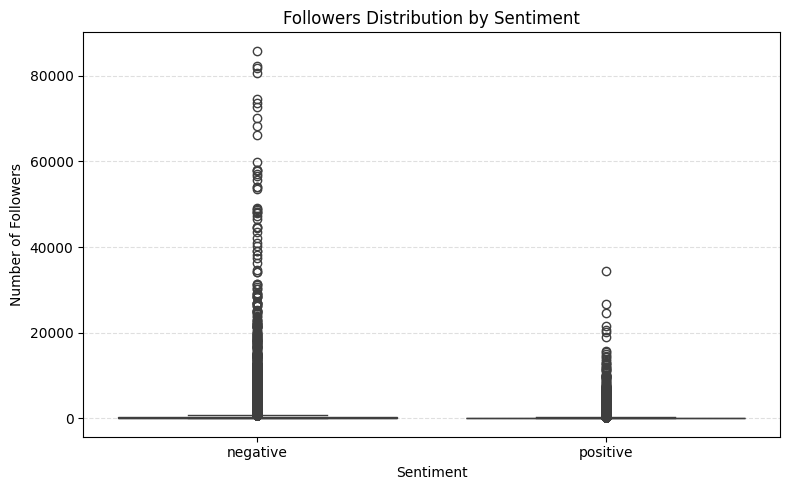

In [ ]:
# Filter rows where 'followers' or 'sentiment' contain '?'
followers_df = df[~df[['followers', 'sentiment']].apply(lambda col: col.astype(str).str.contains('\?')).any(axis=1)].copy()

# Convert 'followers' to numeric and drop NaNs
followers_df['followers'] = pd.to_numeric(followers_df['followers'], errors='coerce')
followers_df = followers_df.dropna(subset=['followers'])

# Limit to avoid extreme outliers
followers_df = followers_df[followers_df['followers'] <= 100000]

# Sort sentiment order
followers_df['sentiment'] = pd.Categorical(followers_df['sentiment'], categories=['negative', 'positive'], ordered=True)

# Create boxplot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=followers_df, x='sentiment', y='followers')

# Manually color the boxes
colors = ['#FF9999', '#99FF99']  # light red and light green

# Loop over boxes and apply color
for i, box in enumerate(ax.patches):
    box.set_facecolor(colors[i % len(colors)])

# Final touches
plt.title('Followers Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Followers')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**Previous Posts Distribution by Sentiment**




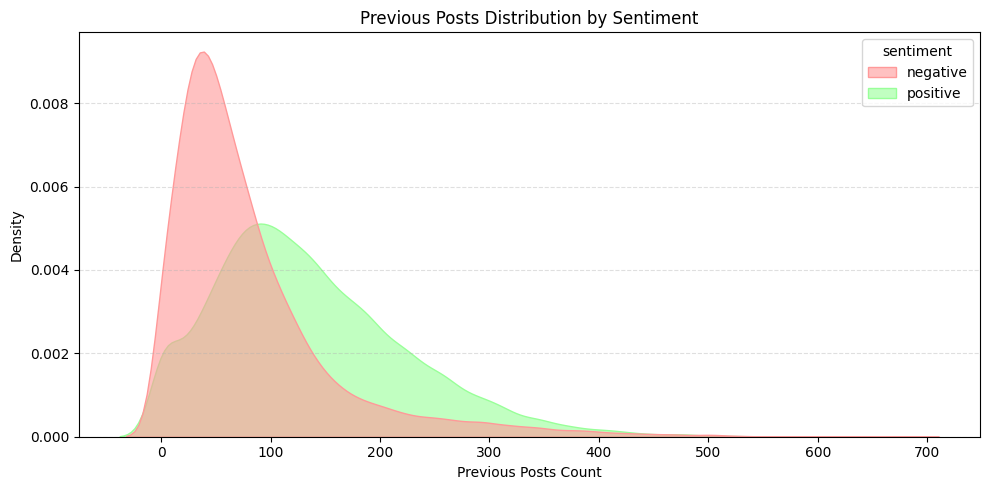

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter valid sentiment values and convert to lowercase
df_clean = df.copy()
df_clean['sentiment'] = df_clean['sentiment'].astype(str).str.strip().str.lower()
df_clean = df_clean[df_clean['sentiment'].isin(['positive', 'negative'])]

# Convert 'previous_posts_count' to numeric
df_clean['previous_posts_count'] = pd.to_numeric(df_clean['previous_posts_count'], errors='coerce')
df_clean = df_clean.dropna(subset=['previous_posts_count'])

# Filter out extreme values (for clearer KDE)
df_clean = df_clean[df_clean['previous_posts_count'] <= 10000]

# Plot KDE
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_clean, x='previous_posts_count', hue='sentiment',
            fill=True, common_norm=False, alpha=0.6,
            palette={'negative': '#FF9999', 'positive': '#99FF99'})

plt.title('Previous Posts Distribution by Sentiment')
plt.xlabel('Previous Posts Count')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**Additional graphs - connections between the variables**

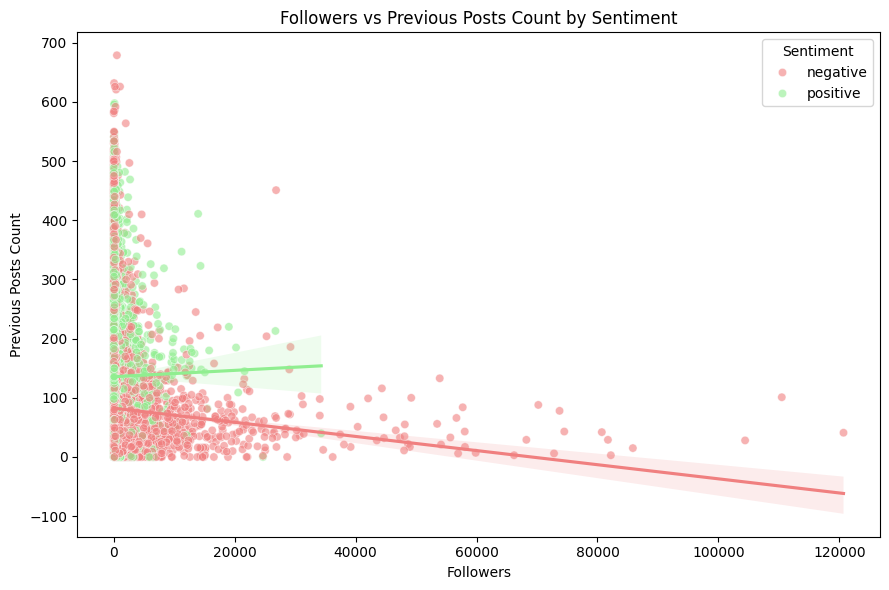

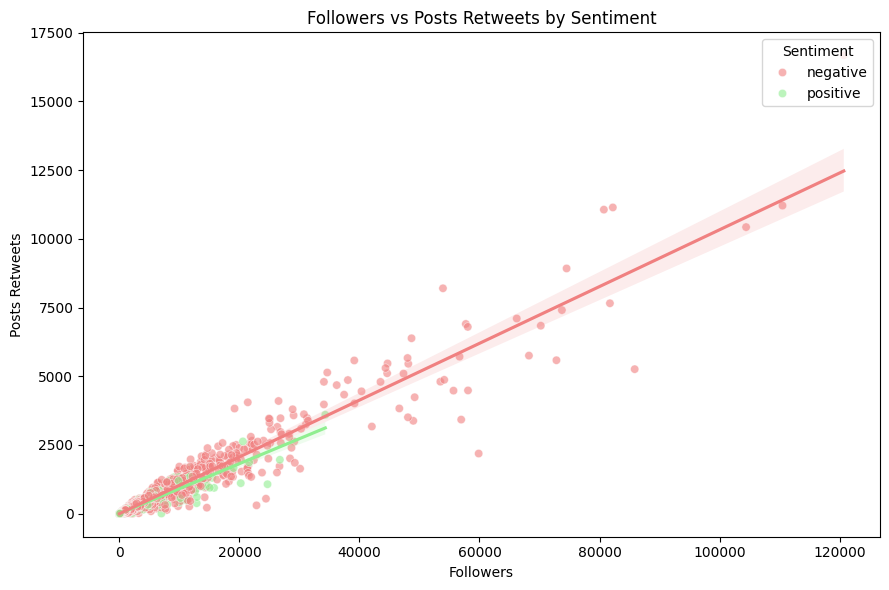

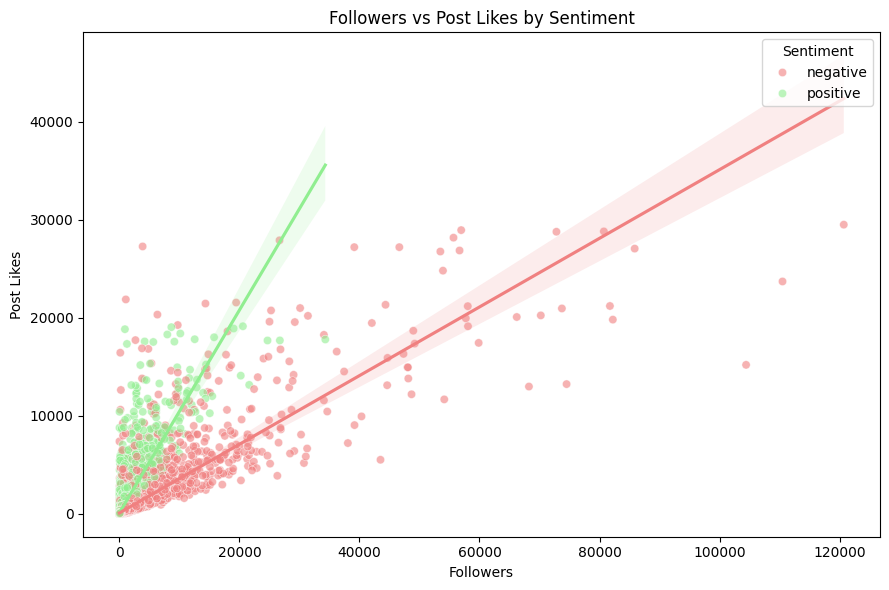

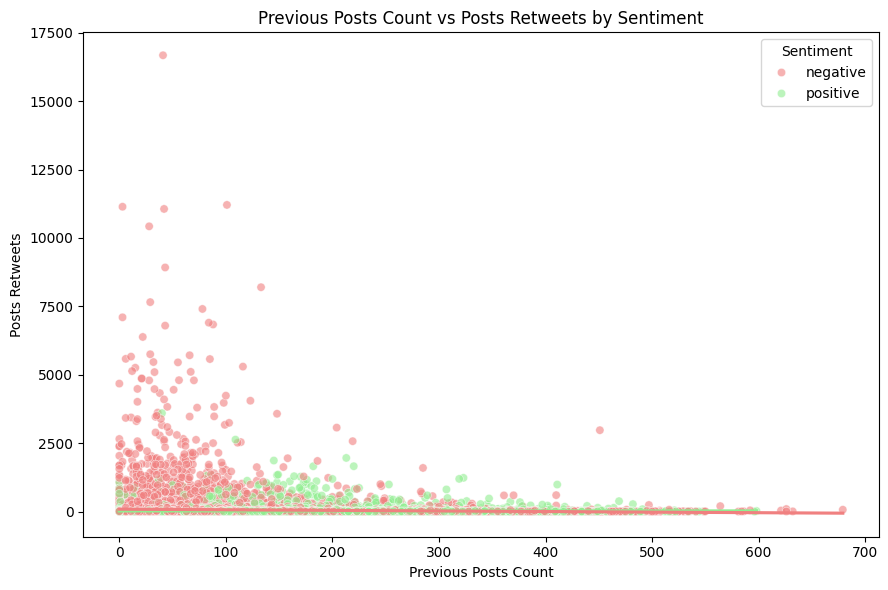

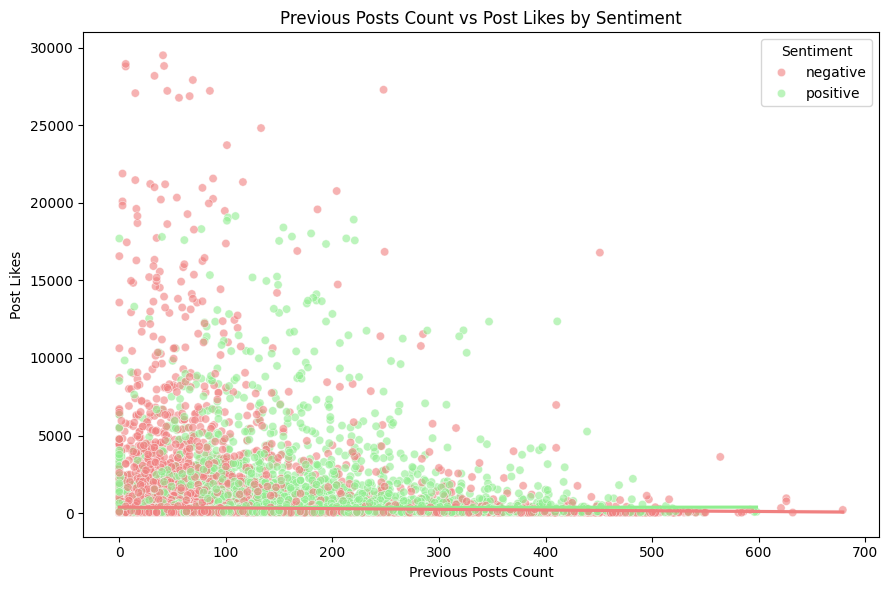

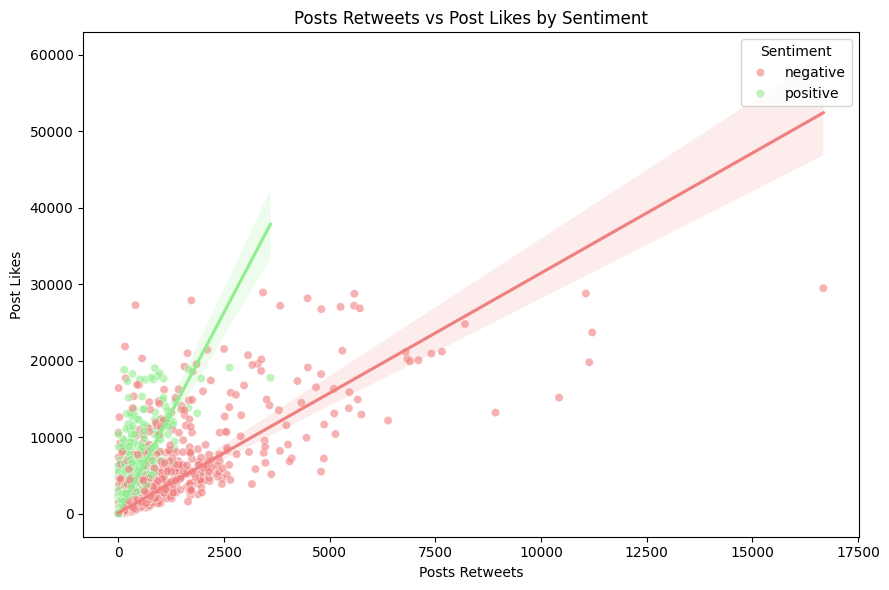

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert selected columns to numeric and handle '?' as NaN
columns_to_clean = ['followers', 'previous_posts_count', 'posts_retweets', 'post_likes']
for col in columns_to_clean:
    df[col] = pd.to_numeric(df[col].replace('?', np.nan), errors='coerce')

# Drop rows with missing values in selected columns
df_clean = df.dropna(subset=columns_to_clean)

# Keep only rows with valid sentiment values
df_clean = df_clean[df_clean['sentiment'].isin(['positive', 'negative'])]
df_clean['sentiment'] = df_clean['sentiment'].str.lower()

# Define color palette for sentiment
palette = {
    'positive': 'lightgreen',
    'negative': 'lightcoral'
}

# Define variable pairs to compare
pairs = [
    ('followers', 'previous_posts_count'),
    ('followers', 'posts_retweets'),
    ('followers', 'post_likes'),
    ('previous_posts_count', 'posts_retweets'),
    ('previous_posts_count', 'post_likes'),
    ('posts_retweets', 'post_likes'),
]

# Create scatter plots with trendlines
for x, y in pairs:
    plt.figure(figsize=(9, 6))

    # Scatterplot with sentiment hue
    sns.scatterplot(data=df_clean, x=x, y=y, hue='sentiment', palette=palette, alpha=0.6)

    # Add regression lines for each sentiment
    sns.regplot(data=df_clean[df_clean['sentiment'] == 'positive'], x=x, y=y,
                scatter=False, color=palette['positive'])
    sns.regplot(data=df_clean[df_clean['sentiment'] == 'negative'], x=x, y=y,
                scatter=False, color=palette['negative'])

    # Plot formatting
    plt.title(f'{x.replace("_", " ").title()} vs {y.replace("_", " ").title()} by Sentiment')
    plt.xlabel(x.replace('_', ' ').title())
    plt.ylabel(y.replace('_', ' ').title())
    plt.legend(title='Sentiment', loc='upper right')
    plt.tight_layout()
    plt.show()


**Correlation matrix**

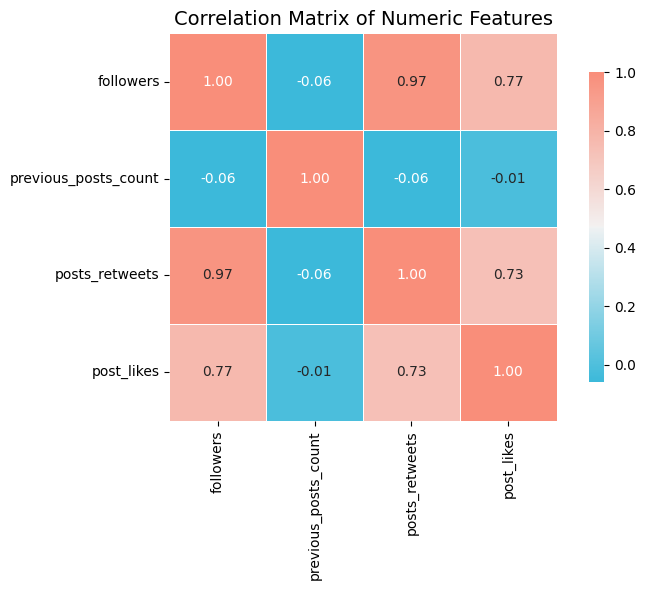

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns and clean data
numeric_cols = ['followers', 'previous_posts_count', 'posts_retweets', 'post_likes']
df_corr = df[numeric_cols].replace('?', pd.NA).astype(float).dropna()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap with soft diverging palette
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=sns.diverging_palette(220, 20, as_cmap=True, s=90, l=70),  # soft version of coolwarm
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()


#Pre proccesing

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://raw.githubusercontent.com/NadavLib/ML/main/sentiment.csv"
df = pd.read_csv(url)

##Redundency

In [53]:
# duplicates check
duplicate_rows = df.duplicated()
print(duplicate_rows.sum())




0


Handling Duplicates – It can be seen that there are no duplicate entries.









##missing values

In [54]:
import pandas as pd

# Lists to store information
columns = []
qmark_counts = []
qmark_percents = []

# Iterate over each column in the DataFrame
for col in df.columns:
    # Count the number of '?' values in the column
    qmark_count = (df[col] == '?').sum()

    # Calculate the percentage of '?' values
    qmark_percent = (qmark_count / len(df)) * 100

    # Append results to the lists
    columns.append(col)
    qmark_counts.append(qmark_count)
    qmark_percents.append(round(qmark_percent, 2))

# Create a summary DataFrame
missing_df = pd.DataFrame({
    'Column': columns,
    'Question Mark Count': qmark_counts,
    'Question Mark %': qmark_percents
})

# Sort the DataFrame by percentage of missing values (descending)
missing_df = missing_df.sort_values(by='Question Mark %', ascending=False).reset_index(drop=True)

# Display the result
missing_df


,Column,Question Mark Count,Question Mark %
0,sentiment,527,1.32
1,timezone,507,1.27
2,post_datetime,507,1.27
3,posts_retweets,486,1.21
4,post_likes,486,1.21
5,birthday,480,1.20
6,account_creation_date,480,1.20
7,checkmark,480,1.20
8,username,480,1.20
9,previous_posts_count,480,1.20


##Dropping Identifier Columns

In [55]:
# drop 'Sentiment' null values from df
df_clean = df[df['sentiment'] != '?']

# drop 'username' column
df_clean = df_clean.drop(columns=['username'])

#drop 'id' column
df_clean = df_clean.drop(columns=['id'])


##Handling Missing values

In [56]:
import pandas as pd

# Lists to store information
columns = []
qmark_counts = []
qmark_percents = []

# Iterate over each column in the DataFrame
for col in df_clean.columns:
    # Count the number of '?' values in the column
    qmark_count = (df_clean[col] == '?').sum()

    # Calculate the percentage of '?' values
    qmark_percent = (qmark_count / len(df_clean)) * 100

    # Append results to the lists
    columns.append(col)
    qmark_counts.append(qmark_count)
    qmark_percents.append(round(qmark_percent, 2))

# Create a summary DataFrame
missing_df = pd.DataFrame({
    'Column': columns,
    'Question Mark Count': qmark_counts,
    'Question Mark %': qmark_percents
})

# Sort the DataFrame by percentage of missing values (descending)
missing_df = missing_df.sort_values(by='Question Mark %', ascending=False).reset_index(drop=True)

# Display the result
missing_df


,Column,Question Mark Count,Question Mark %
0,post_datetime,507,1.28
1,timezone,507,1.28
2,post_likes,486,1.23
3,posts_retweets,486,1.23
4,email,480,1.22
5,account_creation_date,480,1.22
6,checkmark,480,1.22
7,profile_picture,480,1.22
8,followers,480,1.22
9,previous_posts_count,480,1.22


In [57]:


# drop 'post_datetime' null values from df
df_clean = df_clean[df_clean['post_datetime'] != '?']

# drop 'timezone' column
df_clean = df_clean.drop(columns=['timezone'])

# post likes - fill '?' with mean
df_clean['post_likes'] = df_clean['post_likes'].replace('?', np.nan)
df_clean['post_likes'] = pd.to_numeric(df_clean['post_likes']).fillna(df_clean['post_likes'].astype(float).mean())

#'post retweets ' - fill '?' with mean
df_clean['posts_retweets'] = df_clean['posts_retweets'].replace('?', np.nan)
df_clean['posts_retweets'] = pd.to_numeric(df_clean['posts_retweets']).fillna(df_clean['posts_retweets'].astype(float).mean())



# drop 'account_creation_date' '?' values from df
df_clean = df_clean[df_clean['account_creation_date'] != '?']




df_clean.shape


(38486, 14)

In [58]:
import pandas as pd

# Lists to collect info
columns = []
qmark_counts = []
qmark_percents = []

# Loop through columns in df_clean
for col in df_clean.columns:
    qmark_count = (df_clean[col] == '?').sum()
    qmark_percent = (qmark_count / len(df_clean)) * 100

    columns.append(col)
    qmark_counts.append(qmark_count)
    qmark_percents.append(round(qmark_percent, 2))

# Create summary DataFrame
missing_clean_df = pd.DataFrame({
    'Column': columns,
    'Question Mark Count': qmark_counts,
    'Question Mark %': qmark_percents
})

# Sort by highest % missing
missing_clean_df = missing_clean_df.sort_values(by='Question Mark %', ascending=False).reset_index(drop=True)

# Display the result
missing_clean_df


,Column,Question Mark Count,Question Mark %
0,text,0,0.0
1,sentiment,0,0.0
2,type,0,0.0
3,post_datetime,0,0.0
4,post_likes,0,0.0
5,posts_retweets,0,0.0
6,embedded_content_url,0,0.0
7,checkmark,0,0.0
8,account_creation_date,0,0.0
9,email,0,0.0


#data type conversions

In [59]:
#date conversions

df_clean['post_datetime'] = pd.to_datetime(df_clean['post_datetime'], dayfirst=True, errors='coerce')
df_clean['account_creation_date'] = pd.to_datetime(df_clean['account_creation_date'], dayfirst=True, errors='coerce')
df_clean['birthday'] = pd.to_datetime(df_clean['birthday'], dayfirst=True, errors='coerce')


#numeric values

df_clean['followers'] = pd.to_numeric(df_clean['followers'], errors='coerce')
df_clean['previous_posts_count'] = pd.to_numeric(df_clean['previous_posts_count'], errors='coerce')


#first became float because of the handling with missing value phase (used avg)
df_clean['post_likes'] = pd.to_numeric(df_clean['post_likes'], errors='coerce')
df_clean['post_likes'] = df_clean['post_likes'].astype(int)

#first became float because of the handling with missing value phase (used avg)
df_clean['posts_retweets'] = pd.to_numeric(df_clean['posts_retweets'], errors='coerce')
df_clean['posts_retweets'] = df_clean['posts_retweets'].astype(int)



df_clean.info()





<class 'pandas.core.frame.DataFrame'>
Index: 38486 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   text                   38486 non-null  object        
 1   sentiment              38486 non-null  object        
 2   type                   38486 non-null  object        
 3   post_datetime          38486 non-null  datetime64[ns]
 4   post_likes             38486 non-null  int64         
 5   posts_retweets         38486 non-null  int64         
 6   embedded_content_url   8898 non-null   object        
 7   checkmark              38486 non-null  object        
 8   account_creation_date  38486 non-null  datetime64[ns]
 9   email                  38486 non-null  object        
 10  birthday               38486 non-null  datetime64[ns]
 11  followers              38486 non-null  int64         
 12  profile_picture        26985 non-null  object        
 13  previo

#feature extraction

In [61]:
#change 'sentiment' to boolean 1 if positive 0 else
df_clean['sentiment'] = df_clean['sentiment'].replace({'positive': 1, 'negative': 0})
df_clean['sentiment'] = df_clean['sentiment'].astype(int)


#change 'embedded_content_url' to boolean - 1 if there is value' 0 else
df_clean['embedded_content_url'] = df_clean['embedded_content_url'].notna().astype(int)

#change 'profile_picture' to boolean - 1 if there is value' 0 else
df_clean['profile_picture'] = df_clean['profile_picture'].notna().astype(int)

#age column creation
from datetime import datetime

today = pd.Timestamp.now()
df_clean['age'] = ((today - df_clean['birthday']).dt.days // 365)

# Convert the 'account_creation_date' column to datetime
df_clean['account_creation_date'] = pd.to_datetime(df_clean['account_creation_date'], errors='coerce')
# Calculate account age in years
df_clean['account_age_years'] = ((pd.to_datetime('today') - df_clean['account_creation_date']).dt.days / 365).round(2)


#time of day categorization
df_clean['post_hour'] = df_clean['post_datetime'].dt.hour
def time_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'noon'
    else:
        return 'night'

df_clean['time_of_day'] = df_clean['post_hour'].apply(time_of_day)


#domain type classification
def classify_domain(domain):
    personal_domains = {
        'gmail.com', 'hotmail.com', 'outlook.com', 'live.com', 'live.se', 'live.no', 'live.nl', 'live.dk',
        'yahoo.com', 'yahoo.fr', 'yahoo.com.tw', 'yahoo.com.au', 'yahoo.co.uk', 'yahoo.it', 'yahoo.ca',
        'yahoo.de', 'yahoo.co.in', 'yahoo.com.br', 'icloud.com', 'me.com', 'aol.com', 'msn.com',
        'gmx.de', 'mail.ru', 'web.de', 'rocketmail.com', 'bigpond.net.au', 'bigpond.com', 'btinternet.com',
        'naver.com', 'ymail.com', 'libero.it', 'hotmail.co.uk', 'hotmail.fr', 'hotmail.it', '163.com'
    }

    business_domains = {
        'allstate.com', 'statefarm.com', 'shawinc.com', 'remax.net', 'kw.com',
        'cox.net', 'comcast.net', 'att.net', 'bellsouth.net', 'sbcglobal.net'
    }

    academic_keywords = ['.edu', '.ac.', 'moe.edu.sg']

    domain = str(domain).lower()

    if domain in personal_domains:
        return 'personal'
    elif domain in business_domains:
        return 'business'
    elif any(key in domain for key in academic_keywords):
        return 'academic'
    else:
        return 'other'

df_clean['email_domain'] = df_clean['email'].str.extract(r'@([\w\.-]+)')
df_clean['email_category'] = df_clean['email_domain'].apply(classify_domain)



#text length classification
df_clean['text_length'] = df_clean['text'].str.len()

def classify_text_length(n):
    if n <= 80:
        return 'short'
    elif n <= 140:
        return 'medium'
    else:
        return 'long'

df_clean['text_length_category'] = df_clean['text_length'].apply(classify_text_length)

df_clean['text_length_category'].value_counts()




#adds day of the week and is weekend? information

df_clean['day_of_week_raw'] = df_clean['post_datetime'].dt.dayofweek
df_clean['day_of_week'] = ((df_clean['day_of_week_raw'] + 2) % 7).replace(0, 7)
df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)
df_clean['day_of_week'].value_counts()
df_clean = df_clean.drop(columns=['day_of_week_raw'])
df_clean = df_clean.drop(columns=['email_domain'])

#text features
#df_clean['num_words'] = df_clean['text'].str.split().str.len()
df_clean['num_exclamations'] = df_clean['text'].str.count('!')
df_clean['num_hashtags'] = df_clean['text'].str.count('#')
df_clean['likes_per_followers'] = df_clean['post_likes'] / (df_clean['followers'] + 1)
df_clean['posts_per_followers'] = df_clean['previous_posts_count'] / (df_clean['followers'] + 1)








#N-grams

<class 'pandas.core.frame.DataFrame'>
Index: 38486 entries, 0 to 39999
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   bit         38486 non-null  int64
 1   feel        38486 non-null  int64
 2   feel like   38486 non-null  int64
 3   feeling     38486 non-null  int64
 4   im          38486 non-null  int64
 5   im feeling  38486 non-null  int64
 6   ive         38486 non-null  int64
 7   just        38486 non-null  int64
 8   know        38486 non-null  int64
 9   life        38486 non-null  int64
 10  like        38486 non-null  int64
 11  little      38486 non-null  int64
 12  nan         38486 non-null  int64
 13  people      38486 non-null  int64
 14  really      38486 non-null  int64
 15  things      38486 non-null  int64
 16  think       38486 non-null  int64
 17  time        38486 non-null  int64
 18  want        38486 non-null  int64
 19  way         38486 non-null  int64
dtypes: int64(20)
memory usage: 6.2 MB

<ipython-input-62-56d48fca73b2>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ngram_counts.values, y=ngram_counts.index, palette='viridis')


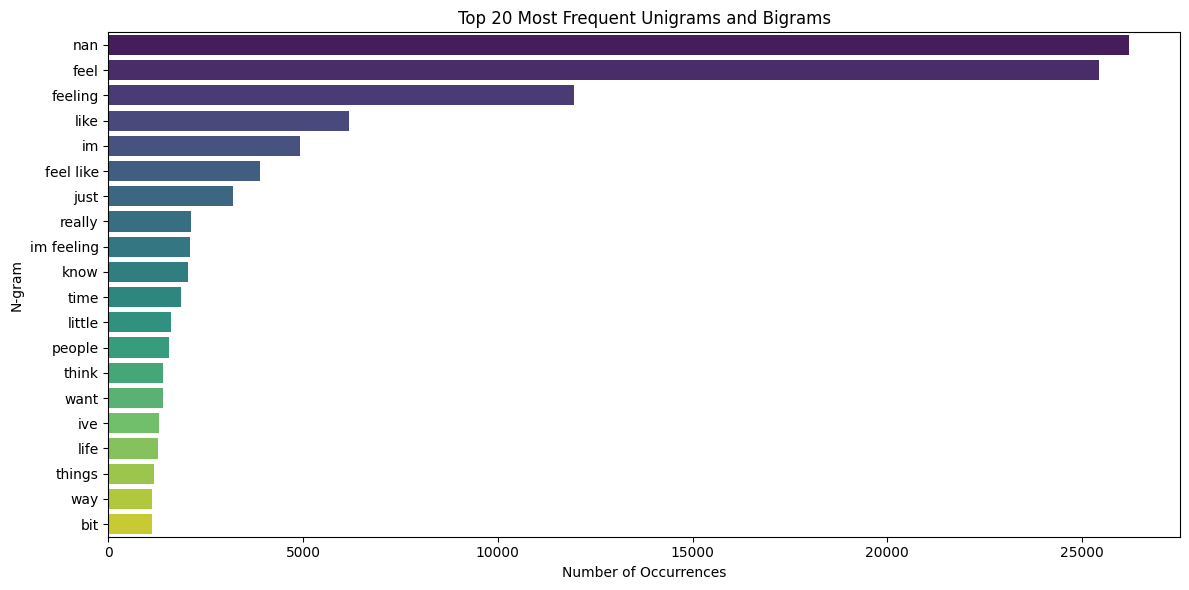

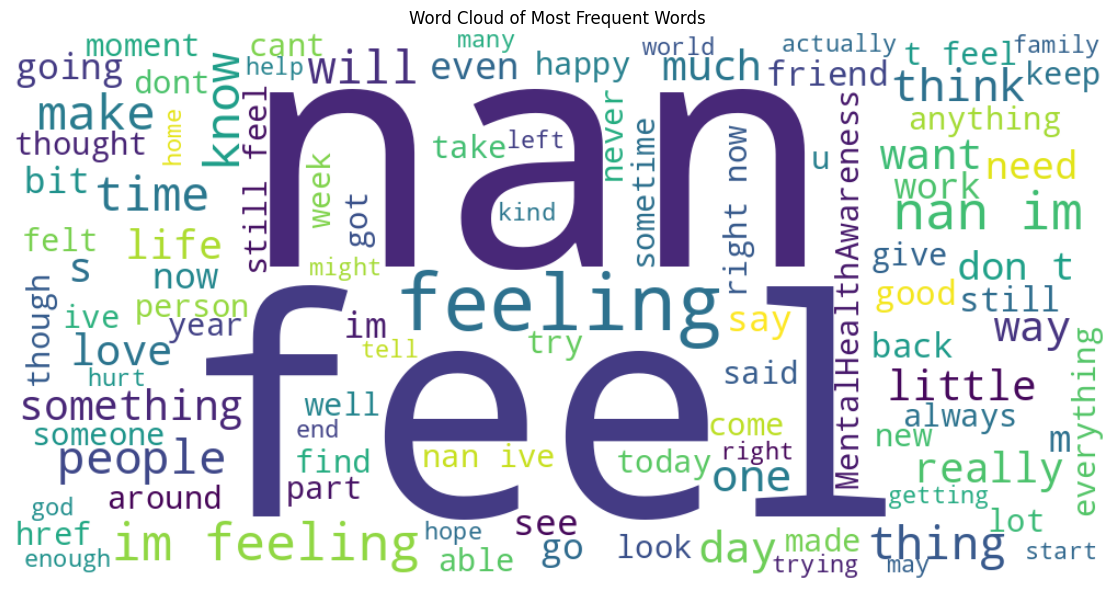

In [62]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the vectorizer on the 'text' column
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=20, stop_words='english', binary=True)

# Apply the vectorizer to the text data
X_ngrams = vectorizer.fit_transform(df_clean['text'])

# Convert the result to a DataFrame
ngrams_df = pd.DataFrame(X_ngrams.toarray(), columns=vectorizer.get_feature_names_out(), index=df_clean.index)
ngrams_df.info()
df_clean = pd.concat([df_clean, ngrams_df], axis=1)

#GRAPHS

# Sum the total occurrences of each n-gram
ngram_counts = ngrams_df.sum().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=ngram_counts.values, y=ngram_counts.index, palette='viridis')
plt.title('Top 20 Most Frequent Unigrams and Bigrams')
plt.xlabel('Number of Occurrences')
plt.ylabel('N-gram')
plt.tight_layout()
plt.show()

from wordcloud import WordCloud, STOPWORDS

# Combine all texts into a single string
text_corpus = " ".join(df_clean['text'].astype(str).tolist())

# Generate and display the word cloud
wordcloud = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='viridis',  # same color palette
    max_words=100
).generate(text_corpus)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words')
plt.tight_layout()
plt.show()


In [ ]:
df_clean

,text,sentiment,type,post_datetime,post_likes,posts_retweets,embedded_content_url,checkmark,account_creation_date,email,...,time_of_day,email_category,text_length,text_length_category,day_of_week,is_weekend,num_exclamations,num_hashtags,likes_per_followers,posts_per_followers
0,i feel selfish when i send a chapter because i...,0,post,2025-08-21 20:35:00,63,31,1,none,2016-06-27,david.green4296@yahoo.it,...,night,personal,109,medium,5,1,0,0,0.172131,0.393443
1,i couldnt help feeling like this scene was goi...,1,retweet,2021-10-13 10:04:00,53,2,0,none,2021-10-12,brianhansen5416@yahoo.com.br,...,morning,personal,100,medium,4,0,0,0,1.606061,0.000000
2,i liked it for its free feeling and i really l...,1,reply,2022-03-08 09:21:00,51,4,0,none,2018-04-07,thomas_williams4935@live.nl,...,morning,personal,112,medium,3,0,0,0,1.062500,1.875000
3,i retreat ended i woke up feeling extremely ag...,0,post,2023-02-04 20:32:00,28,4,1,blue,2023-02-03,michaelmiller1564@yahoo.com,...,night,personal,56,short,7,1,0,0,2.000000,0.000000
4,i have been thinking hard about all that feeli...,0,post,2025-11-13 15:30:00,51,14,1,none,2019-04-26,robertfox3470@bellsouth.net,...,noon,business,222,long,5,1,0,3,0.428571,0.411765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,i feel hated by my parents nan,0,reply,2023-12-18 02:20:00,74,8,0,none,2023-12-17,michael564@libero.it,...,night,personal,30,short,2,0,0,0,0.672727,0.000000
39996,i feel really honoured because in the guitar w...,1,reply,2022-11-23 10:33:00,162,4,1,none,2019-04-21,bradley_nash777@gmx.de,...,morning,personal,119,medium,4,0,0,3,1.542857,1.428571
39997,i wore casual clothing without feeling awkward...,0,reply,2021-11-20 00:00:00,837,131,1,none,2016-04-26,joseph_white2074@gmail.com,...,night,personal,66,short,7,1,0,0,0.802493,0.060403
39998,i have come to firmly believe that no matter h...,0,reply,2025-01-18 03:42:00,97,7,1,grey,2021-01-18,gerald_miller6809@yahoo.ca,...,night,personal,123,medium,7,1,0,0,0.655405,0.425676


#feature representation

##category cloumns

In [63]:
# columns to categorize
cols_to_binary = ['email_category', 'time_of_day', 'text_length_category', 'type','checkmark', 'day_of_week']

# save the columns names before categorize
cols_before = df_clean.columns.tolist()

# Convert numeric day_of_week to weekday names
day_name_map = {
    1: 'sunday', 2: 'monday', 3: 'tuesday', 4: 'wednesday',
    5: 'thursday', 6: 'friday', 7: 'saturday'
}
df_clean['day_of_week'] = df_clean['day_of_week'].map(day_name_map)


# no drop_first to keep all categories
df_clean = pd.get_dummies(df_clean, columns=cols_to_binary, drop_first=False)

# Identify the new columns added
new_cols = [col for col in df_clean.columns if col not in cols_before]

# Convert new dummy variables to integers (0/1)
df_clean[new_cols] = df_clean[new_cols].astype(int)


##standarize numeric values

In [64]:
from sklearn.preprocessing import MinMaxScaler

# List of numeric features to normalize
numeric_features = [
    'followers',
    'previous_posts_count',
    'post_likes',
    'posts_retweets',
    'likes_per_followers',
    'posts_per_followers',
    'num_exclamations',
    'num_hashtags',
    'account_age_years',
    'age' ,
]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply the scaler on the selected columns
df_clean[numeric_features] = scaler.fit_transform(df_clean[numeric_features])
df_clean
print(df_clean.columns)

columns_to_drop = [            #columns that we converted to categories/ binary / other
    'checkmark',               # checkmark_blue/gold/grey/none
    'type',                    # type_post/reply/retweet
    'email',                   # email_category
    'text_length',             # text_length_category
    'post_datetime',           # day_of_week, is weekend
    'embedded_content_url',    # binary variable
    'account_creation_date',   # account_age_years
    'birthday' ,               # age
    'text'  ,                   #ngrams, text_length_category (short, medium, long)
    'post_hour'  ,             # time_of_day
]
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

df_clean
# Check data types of all columns
print(df_clean.dtypes)


Index(['text', 'sentiment', 'post_datetime', 'post_likes', 'posts_retweets',
       'embedded_content_url', 'account_creation_date', 'email', 'birthday',
       'followers', 'profile_picture', 'previous_posts_count', 'age',
       'account_age_years', 'post_hour', 'text_length', 'is_weekend',
       'num_exclamations', 'num_hashtags', 'likes_per_followers',
       'posts_per_followers', 'bit', 'feel', 'feel like', 'feeling', 'im',
       'im feeling', 'ive', 'just', 'know', 'life', 'like', 'little', 'nan',
       'people', 'really', 'things', 'think', 'time', 'want', 'way',
       'email_category_academic', 'email_category_business',
       'email_category_other', 'email_category_personal',
       'time_of_day_morning', 'time_of_day_night', 'time_of_day_noon',
       'text_length_category_long', 'text_length_category_medium',
       'text_length_category_short', 'type_post', 'type_reply', 'type_retweet',
       'checkmark_blue', 'checkmark_gold', 'checkmark_grey', 'checkmark_none',
   

In [69]:
df_clean


,sentiment,post_likes,posts_retweets,followers,profile_picture,previous_posts_count,age,account_age_years,is_weekend,num_exclamations,...,checkmark_gold,checkmark_grey,checkmark_none,day_of_week_friday,day_of_week_monday,day_of_week_saturday,day_of_week_sunday,day_of_week_thursday,day_of_week_tuesday,day_of_week_wednesday
0,0,0.001486,0.002766,0.003304,1,0.212077,0.065934,0.443357,1,0.0,...,0,0,1,0,0,0,0,1,0,0
1,1,0.001141,0.000178,0.000290,1,0.000000,0.197802,0.196270,0,0.0,...,0,0,1,0,0,0,0,0,0,1
2,1,0.001072,0.000357,0.000425,1,0.132548,0.340659,0.360373,0,0.0,...,0,0,1,0,0,0,0,0,1,0
3,0,0.000277,0.000357,0.000118,1,0.000000,0.285714,0.135198,1,0.0,...,0,0,0,0,0,1,0,0,0,0
4,0,0.001072,0.001249,0.001068,1,0.072165,0.274725,0.311422,1,0.0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0,0.001867,0.000714,0.000987,1,0.000000,0.219780,0.094639,0,0.0,...,0,0,1,0,1,0,0,0,0,0
39996,1,0.004908,0.000357,0.000941,1,0.220913,0.285714,0.311888,0,0.0,...,0,0,1,0,0,0,0,0,0,1
39997,0,0.028241,0.011687,0.009431,1,0.092784,0.208791,0.451282,1,0.0,...,0,0,1,0,0,1,0,0,0,0
39998,0,0.002662,0.000624,0.001331,1,0.092784,0.197802,0.230303,1,0.0,...,0,1,0,0,0,1,0,0,0,0


#Feature selection

In [70]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Separate features and target
X_full = df_clean.drop(columns=['sentiment'])
y = df_clean['sentiment']

# Select only numeric columns for Fisher Score
X = X_full.select_dtypes(include=[np.number])

# Handle missing values using mean imputation
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Select top 25 features using Fisher Score
k = 25
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_imputed, y)

# Get selected feature names
selected_columns = X.columns[selector.get_support()]
df_selected = pd.DataFrame(X_selected, columns=selected_columns)

# Add sentiment column back
df_selected['sentiment'] = y.values

# Show Fisher Scores
scores = selector.scores_[selector.get_support()]
feature_scores = pd.DataFrame({
    'Feature': selected_columns,
    'Fisher Score': scores
}).sort_values(by='Fisher Score', ascending=False)

print("Top 25 Selected Features:")
print(feature_scores)




Top 25 Selected Features:
                        Feature  Fisher Score
4                  num_hashtags  11340.705761
14                          nan   9491.173254
2          previous_posts_count   4048.084810
22               checkmark_gold   1894.253040
23               checkmark_grey   1888.721654
20   text_length_category_short   1875.700122
24               checkmark_none   1485.753551
18    text_length_category_long   1353.986259
16            time_of_day_night   1243.850869
15          time_of_day_morning    958.428408
6           posts_per_followers    440.211281
1                     followers    312.700779
0                posts_retweets    291.634040
5           likes_per_followers    260.691883
3                           age    225.000135
21               checkmark_blue    142.977321
7                           bit    109.569501
8                          feel     89.090052
10                      feeling     85.245293
17             time_of_day_noon     81.616180
11      

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3 8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [71]:
# Create a clean table with ranking
feature_scores_sorted = feature_scores.reset_index(drop=True)
feature_scores_sorted.index = feature_scores_sorted.index + 1  # Start ranking from 1
feature_scores_sorted.rename(columns={"Feature": "Feature Name", "Fisher Score": "Fisher Score"}, inplace=True)

# Display table
print(feature_scores_sorted)

# Export to CSV
feature_scores_sorted.to_csv("selected_features_fisher_scores.csv", index_label="Rank")


                   Feature Name  Fisher Score
1                  num_hashtags  11340.705761
2                           nan   9491.173254
3          previous_posts_count   4048.084810
4                checkmark_gold   1894.253040
5                checkmark_grey   1888.721654
6    text_length_category_short   1875.700122
7                checkmark_none   1485.753551
8     text_length_category_long   1353.986259
9             time_of_day_night   1243.850869
10          time_of_day_morning    958.428408
11          posts_per_followers    440.211281
12                    followers    312.700779
13               posts_retweets    291.634040
14          likes_per_followers    260.691883
15                          age    225.000135
16               checkmark_blue    142.977321
17                          bit    109.569501
18                         feel     89.090052
19                      feeling     85.245293
20             time_of_day_noon     81.616180
21                         just   

#Dimensionality reduction

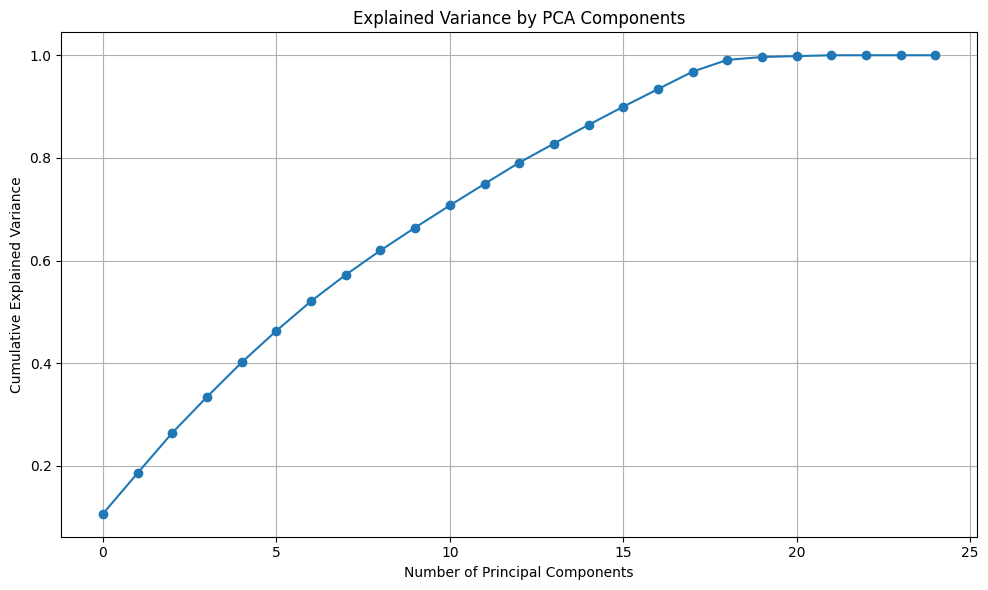

   Component  Explained Variance %  Cumulative %
0        PC1                 10.67         10.67
1        PC2                  7.93         18.60
2        PC3                  7.84         26.44
3        PC4                  7.00         33.44
4        PC5                  6.72         40.16
5        PC6                  6.16         46.32
6        PC7                  5.76         52.08
7        PC8                  5.15         57.23
8        PC9                  4.74         61.97
9       PC10                  4.45         66.43
10      PC11                  4.31         70.74
11      PC12                  4.21         74.94
12      PC13                  4.14         79.08
13      PC14                  3.71         82.79
14      PC15                  3.65         86.44
15      PC16                  3.54         89.98
16      PC17                  3.42         93.40


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Separate features and target
X_pca = df_selected.drop(columns=['sentiment'])
y = df_selected['sentiment']

# Standardize the features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA()
X_pca_components = pca.fit_transform(X_scaled)


#---------------

# Plot explained variance ratio for each component
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.tight_layout()
plt.show()

#---------------

# Table of explained variance per component
explained_variance_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance %': np.round(pca.explained_variance_ratio_ * 100, 2),
    'Cumulative %': np.round(np.cumsum(pca.explained_variance_ratio_) * 100, 2)
})

print(explained_variance_df.head(17))  # Show first 17 components


In [ ]:
# Keep only the first 17 components
X_pca_17 = X_pca_components[:, :17]

# Convert to DataFrame with proper column names
pca_17_df = pd.DataFrame(X_pca_17, columns=[f'PC{i+1}' for i in range(17)])

# Add the sentiment column
pca_17_df['sentiment'] = y.values

# Save to CSV
pca_17_df.to_csv("pca_17_data.csv", index=False)


#Validation

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score


# Define the feature set and the target
X = pca_17_df.drop(columns=['sentiment'])
y = pca_17_df['sentiment']

# Initialize the model
model = LogisticRegression(max_iter=1000)

# Define evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# Set up 10-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Run cross-validation and collect results
cv_results = cross_validate(model, X, y, cv=kfold, scoring=scoring)

# Print performance summary
print("Model performance using 10-Fold Cross Validation:\n")
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    print(f"{metric.capitalize()}: {scores.mean():.4f} ± {scores.std():.4f}")


Model performance using 10-Fold Cross Validation:

Accuracy: 0.7717 ± 0.0076
Precision: 0.7656 ± 0.0108
Recall: 0.6858 ± 0.0126
F1: 0.7234 ± 0.0096
